# Turnout Lab — leakage-aware attendance modeling

## tl;dr

The supplied test set is not independent: all **100 of 100** test rows match training identities and features. Turnout Lab quarantines **101** matching training rows before model development, leaving **397** leakage-safe labeled registrations.

The selected calibrated random forest achieved mean repeated-CV ROC-AUC **0.635**, macro-F1 **0.584**, Brier score **0.221**, and top-20% no-show lift **1.52×**. The signal is modest, so the model is suitable for supportive reminder prioritization—not punitive or deterministic decisions.

## Context & Methods

This notebook is the inspectable companion to reusable code in `src/turnout_lab`. It verifies the data-quality evidence, model comparison, calibration, and required test output without duplicating the training implementation.

### Key assumptions

- One row represents one student registration for one event.
- Only information available at registration time is used.
- Student ID is an identifier and never a model feature.
- Matching official-test rows are quarantined before targets are used.
- No event ID or calendar date is supplied, so event-level or temporal validation is impossible.
- Reported patterns are associations, not causal effects.

**Sources:** the official challenge document and spreadsheet URLs are recorded with SHA-256 hashes in `data/raw/provenance.json`.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd

from turnout_lab.config import METRICS_PATH, PREDICTIONS_PATH, QUALITY_REPORT_PATH, TEST_PATH, TRAIN_PATH
from turnout_lab.data import feature_fingerprint, prepare_datasets

prepared = prepare_datasets(TRAIN_PATH, TEST_PATH)
metrics = json.loads(METRICS_PATH.read_text(encoding="utf-8"))
quality = json.loads(QUALITY_REPORT_PATH.read_text(encoding="utf-8"))
diagnostics = metrics["decision_diagnostics"]

## Data

In [2]:
profile = pd.DataFrame(
    [
        {"stage": "Raw training", "rows": quality["raw"]["train_rows"], "purpose": "Supplied source"},
        {"stage": "Official test", "rows": quality["raw"]["test_rows"], "purpose": "Required predictions"},
        {"stage": "Quarantined train", "rows": quality["overlap"]["quarantined_training_rows"], "purpose": "Excluded from all modeling"},
        {"stage": "Development cohort", "rows": quality["development"]["rows"], "purpose": "Grouped validation and final fit"},
    ]
)
profile

,stage,rows,purpose
0,Raw training,508,Supplied source
1,Official test,100,Required predictions
2,Quarantined train,101,Excluded from all modeling
3,Development cohort,397,Grouped validation and final fit


In [3]:
development_ids = set(prepared.development["student_id"].astype(str))
test_ids = set(prepared.test["student_id"].astype(str))
development_fingerprints = set(feature_fingerprint(prepared.development))
test_fingerprints = set(feature_fingerprint(prepared.test))

leakage_checks = {
    "identity_overlap_after_quarantine": len(development_ids & test_ids),
    "feature_overlap_after_quarantine": len(development_fingerprints & test_fingerprints),
    "student_id_used_as_feature": False,
}
assert leakage_checks["identity_overlap_after_quarantine"] == 0
assert leakage_checks["feature_overlap_after_quarantine"] == 0
leakage_checks

{'identity_overlap_after_quarantine': 0,
 'feature_overlap_after_quarantine': 0,
 'student_id_used_as_feature': False}

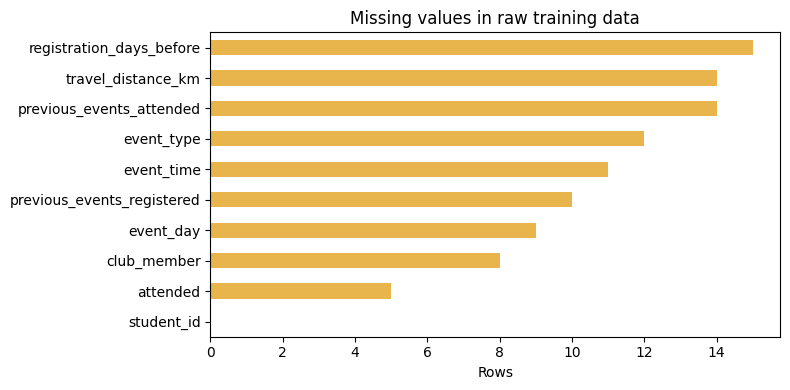

In [4]:
missing = pd.Series(quality["raw"]["train_missing_by_column"]).sort_values()
ax = missing.plot.barh(figsize=(8, 4), color="#E8B44C", title="Missing values in raw training data")
ax.set_xlabel("Rows")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## Results

In [5]:
candidate_rows = []
for summary in metrics["candidate_summaries"]:
    candidate_rows.append(
        {
            "candidate": summary["label"],
            "roc_auc": summary["roc_auc"]["mean"],
            "macro_f1": summary["macro_f1"]["mean"],
            "brier": summary["brier"]["mean"],
        }
    )
candidates = pd.DataFrame(candidate_rows).sort_values("roc_auc", ascending=False)
candidates.style.format({"roc_auc": "{:.3f}", "macro_f1": "{:.3f}", "brier": "{:.3f}"})

,candidate,roc_auc,macro_f1,brier
3,random_forest · raw,0.638,0.590,0.227
4,random_forest · engineered,0.628,0.577,0.231
5,gradient_boosting · raw,0.607,0.559,0.227
6,gradient_boosting · engineered,0.601,0.568,0.227
1,logistic_regression · raw,0.587,0.557,0.232
2,logistic_regression · engineered,0.580,0.558,0.246
0,dummy · raw,0.500,0.375,0.233


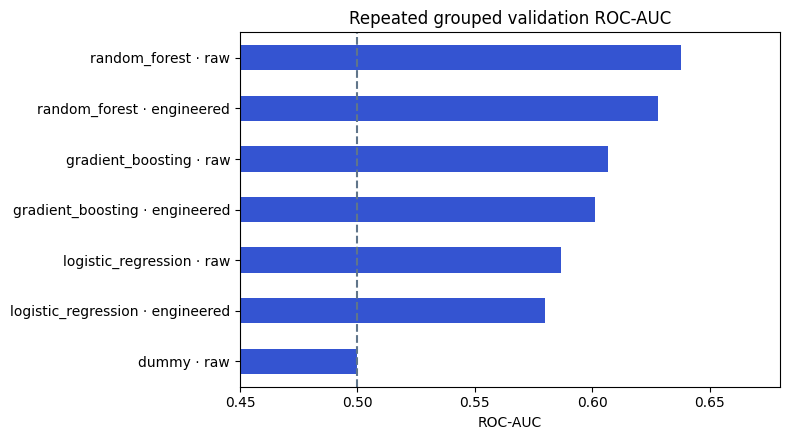

In [6]:
ax = candidates.sort_values("roc_auc").plot.barh(
    x="candidate", y="roc_auc", figsize=(8, 4.5), color="#3454D1", legend=False,
    title="Repeated grouped validation ROC-AUC"
)
ax.axvline(0.5, color="#60758A", linestyle="--", label="No discrimination")
ax.set_xlim(0.45, 0.68)
ax.set_xlabel("ROC-AUC")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

### Decision diagnostics

A probability model becomes a classification policy only after choosing a threshold. The next views show the precision/recall trade-off at alternative thresholds, the error profile at the final threshold, and stability across the 25 grouped outer folds. Each development row is evaluated once per outer seed. Headline class metrics average fold-local thresholds; the confusion matrix applies the final 0.59 policy uniformly, so the two summaries answer different questions.

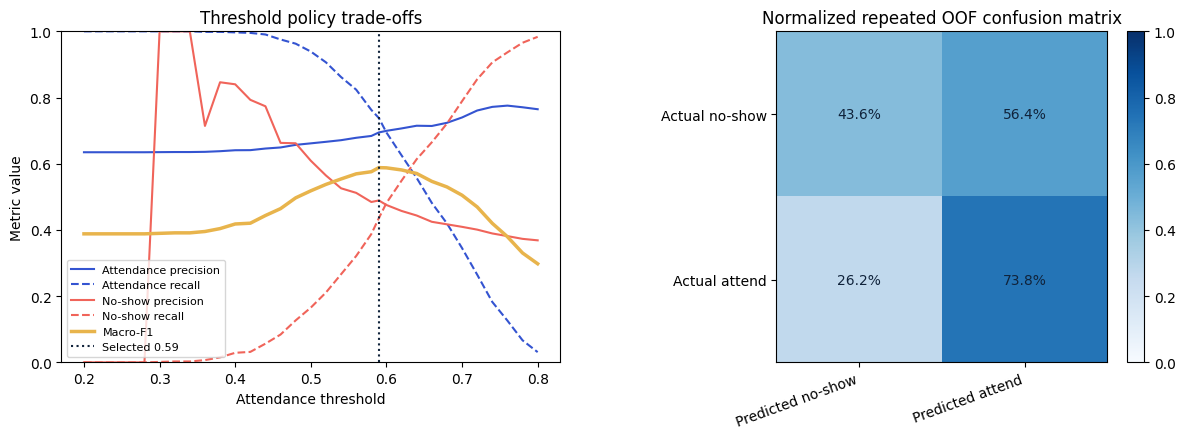

In [7]:
threshold_curve = pd.DataFrame(diagnostics["threshold_curve"])
selected_threshold = diagnostics["selected_threshold"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(threshold_curve["threshold"], threshold_curve["attendance_precision"], color="#3454D1", label="Attendance precision")
axes[0].plot(threshold_curve["threshold"], threshold_curve["attendance_recall"], color="#3454D1", linestyle="--", label="Attendance recall")
axes[0].plot(threshold_curve["threshold"], threshold_curve["no_show_precision"], color="#F0645A", label="No-show precision")
axes[0].plot(threshold_curve["threshold"], threshold_curve["no_show_recall"], color="#F0645A", linestyle="--", label="No-show recall")
axes[0].plot(threshold_curve["threshold"], threshold_curve["macro_f1"], color="#E8B44C", linewidth=2.5, label="Macro-F1")
axes[0].axvline(selected_threshold, color="#10233B", linestyle=":", label=f"Selected {selected_threshold:.2f}")
axes[0].set(xlabel="Attendance threshold", ylabel="Metric value", ylim=(0, 1), title="Threshold policy trade-offs")
axes[0].legend(fontsize=8)

confusion = pd.DataFrame(
    diagnostics["normalized_confusion_matrix"],
    index=["Actual no-show", "Actual attend"],
    columns=["Predicted no-show", "Predicted attend"],
)
image = axes[1].imshow(confusion, cmap="Blues", vmin=0, vmax=1)
for row in range(2):
    for column in range(2):
        axes[1].text(column, row, f"{confusion.iloc[row, column]:.1%}", ha="center", va="center", color="#10233B")
axes[1].set_xticks(range(2), confusion.columns, rotation=20, ha="right")
axes[1].set_yticks(range(2), confusion.index)
axes[1].set_title("Normalized repeated OOF confusion matrix")
fig.colorbar(image, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

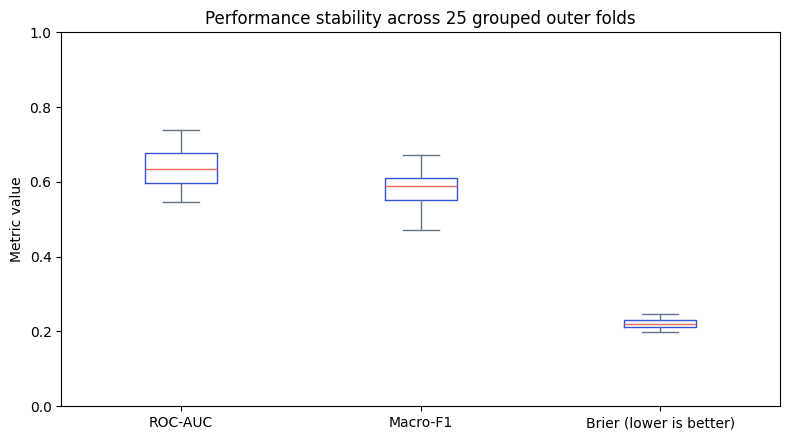

In [8]:
fold_metrics = pd.DataFrame(metrics["calibrated_champion"]["fold_metrics"])
stability = fold_metrics[["roc_auc", "macro_f1", "brier"]].rename(
    columns={"roc_auc": "ROC-AUC", "macro_f1": "Macro-F1", "brier": "Brier (lower is better)"}
)
ax = stability.plot.box(figsize=(8, 4.5), color=dict(boxes="#3454D1", whiskers="#60758A", medians="#F0645A", caps="#60758A"))
ax.set(title="Performance stability across 25 grouped outer folds", ylabel="Metric value", ylim=(0, 1))
plt.tight_layout()
plt.show()

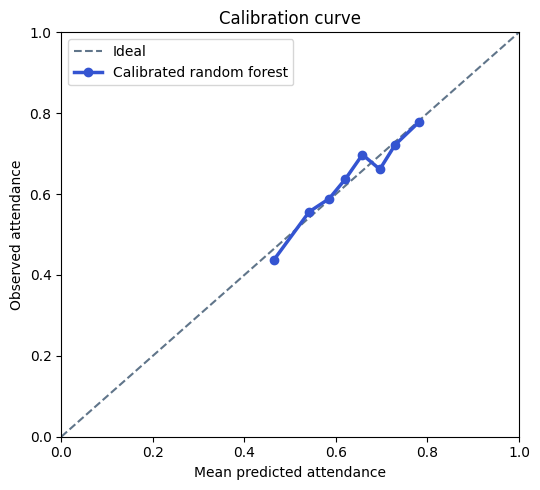

In [9]:
calibration = pd.DataFrame(metrics["calibrated_champion"]["calibration_points"])
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot([0, 1], [0, 1], "--", color="#60758A", label="Ideal")
ax.plot(
    calibration["mean_predicted_probability"],
    calibration["observed_attendance_rate"],
    marker="o", color="#3454D1", linewidth=2.5, label="Calibrated random forest"
)
ax.set(xlabel="Mean predicted attendance", ylabel="Observed attendance", title="Calibration curve", xlim=(0, 1), ylim=(0, 1))
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
event_insights = pd.DataFrame(metrics["descriptive_insights"]["event_type"])
event_insights.style.format({
    "attendance_rate": "{:.1%}", "ci_95_low": "{:.1%}", "ci_95_high": "{:.1%}"
})

,attendance_rate,ci_95_high,ci_95_low,n,segment
0,75.9%,83.0%,67.9%,112,workshop
1,66.7%,76.5%,56.8%,81,talk
2,62.5%,87.5%,25.0%,8,missing
3,56.1%,68.2%,43.9%,66,competition
4,55.4%,67.7%,43.1%,65,hackathon
5,53.8%,64.6%,41.5%,65,social


### Three planning insights

- Workshops recorded **75.9% attendance** (`n=112`) versus **53.8%** for social events (`n=65`).
- Club members recorded **68.9% attendance** (`n=251`) versus **53.2%** for non-members (`n=141`).
- Registrations made 8–14 days early recorded **73.4% attendance** (`n=188`) versus **48.6%** for registrations made 1–3 days early (`n=72`).

These are descriptive associations with bootstrap uncertainty, not evidence that changing an event or registration field will cause the observed difference.

In [11]:
predictions = pd.read_csv(PREDICTIONS_PATH)
assert len(predictions) == 100
assert predictions["student_id"].nunique() == 100
assert predictions["attendance_probability"].between(0, 1).all()
assert predictions["error"].fillna("").eq("").all()
predictions[[
    "student_id", "attendance_probability", "no_show_probability",
    "predicted_attendance", "no_show_risk_band", "reliability"
]].head(10)

,student_id,attendance_probability,no_show_probability,predicted_attendance,no_show_risk_band,reliability
0,S1379,0.765561,0.234439,True,low,medium
1,S1425,0.629239,0.370761,True,medium,high
2,S1273,0.437445,0.562555,False,high,high
3,S1028,0.677484,0.322516,True,low,medium
4,S1259,0.518913,0.481087,False,high,high
5,S1409,0.612671,0.387329,True,medium,high
6,S1494,0.710682,0.289318,True,low,high
7,S1204,0.612779,0.387221,True,medium,high
8,S1166,0.552289,0.447711,False,high,high
9,S1388,0.688125,0.311875,True,low,high


## Takeaways

1. **Evaluation integrity matters more than a flattering score.** The official test overlap is quarantined; reported performance comes from 25 grouped outer folds.
2. **The signal is modest but operationally useful.** Mean ROC-AUC is 0.635; the highest-risk 20% captures 30.6% of no-shows at 1.52× lift.
3. **Probability is not reliability.** Calibration, input-contract checks, and out-of-distribution warnings are surfaced separately in the app.
4. **Use the output supportively.** Send reminders, plan capacity, or investigate patterns. Do not deny registrations or penalize students based on a score.

The absence of event identifiers, timestamps, demographics, and a genuinely independent test set limits both generalization claims and fairness analysis.